
# 🌿 Leaf Lesion Segmentation → Disease Severity Scoring Pipeline
### End-to-end, reproducible, production-ready pipeline (Google Colab)

**Dataset:** [`leaf-lesion-segmentation-qfbaa`](https://universe.roboflow.com/balajicv/leaf-lesion-segmentation-qfbaa) (Roboflow Universe, CC BY 4.0)

**Pipeline stages**
1. **Task 1 — Automated Data Ingestion & Validation**: programmatic Roboflow download + split/dimension/class-balance checks.
2. **Task 2 — Integrated Hybrid Pipeline (DL + VLM)**: fine-tune YOLOv8-seg → pixel-ratio severity scoring → open-source VLM (Qwen2.5-VL) as a structured visual critique/validation layer.
3. **Task 3 — Metric Evaluation & Cross-Verification Diagnostics**: Mask mAP@50, severity MAE, DL-vs-VLM cross-verification matrix, failure-mode visualizations.
4. **Task 4 — Multi-Model Packaging & Serving**: ONNX/TensorRT export + FastAPI/Docker/edge serving design.

> **Runtime:** Colab GPU runtime (T4 or better). `Runtime → Change runtime type → GPU`.
> **Citation:**
> ```
> @misc{ leaf-lesion-segmentation-qfbaa_dataset,
>   title = { leaf lesion segmentation Dataset }, type = { Open Source Dataset },
>   author = { balajiCV }, howpublished = { \\url{ https://universe.roboflow.com/balajicv/leaf-lesion-segmentation-qfbaa } },
>   journal = { Roboflow Universe }, publisher = { Roboflow }, year = { 2025 }, month = { nov } }
> ```


## 0. Environment Setup

In [1]:

# ============================================================
# 0.1 Install dependencies
# ============================================================
!pip install -q ultralytics==8.3.* roboflow inference-sdk supervision \
    transformers accelerate bitsandbytes qwen-vl-utils \
    onnx onnxruntime-gpu onnxslim \
    fastapi uvicorn pillow opencv-python-headless matplotlib seaborn pandas pyyaml tqdm

print("Dependencies installed.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 2.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 13.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.1/377.1 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 41.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.2/202.2 MB 9.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.0/239.0 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 71.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 51.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 27.0 MB/

In [2]:

# ============================================================
# 0.2 GPU / environment check
# ============================================================
import torch, platform, subprocess

print("Python:", platform.python_version())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU (T4).")


Python: 3.12.13
Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM (GB): 15.6


In [3]:

# ============================================================
# 0.3 Global config — edit these
# ============================================================
import os

CONFIG = {
    # Roboflow
    "ROBOFLOW_API_KEY": "iXH4R54n8HqJufMk4oIV",   # replace with your own key from roboflow.com/settings/api
    "RF_WORKSPACE": "balajicv",
    "RF_PROJECT": "leaf-lesion-segmentation-qfbaa",
    "RF_VERSION": 1,                               # check the "Versions" tab on Universe if this differs
    "RF_FORMAT": "yolov8",                         # instance-seg polygon export

    # Class semantics — PLACEHOLDER ONLY. The only class names actually confirmed from the
    # dataset owner's own workflow snippet are "leaf" and "spot" (see the `parameters`
    # dict in the "general-segmentation-api" workflow call in the dataset's README).
    # "rust"/"black_rot"/"blight" below are NOT confirmed — they were carried over from the
    # task prompt's example disease list, not from inspecting this dataset. Cell 1.1 prints
    # the real `data_yaml["names"]` after download — READ THAT OUTPUT and edit these two
    # lists to match it exactly before running Task 2.
    # "LEAF_CLASS_NAMES": ["leaf"],
    # "LESION_CLASS_NAMES": ["spot"],
    "LEAF_CLASS_NAMES": ["0"],
    "LESION_CLASS_NAMES": ["1"],# add any additional confirmed lesion class names here

    # Training
    "MODEL_ARCH": "yolov8n-seg.pt",   # swap for yolov8n-seg.pt (fast) or yolo11s-seg.pt
    "EPOCHS": 50,
    "IMG_SIZE": 512,
    "BATCH": 32,
    "PROJECT_DIR": "runs/severity_seg",
    "RUN_NAME": "leaf_lesion_seg",

    # VLM
    "VLM_MODEL_ID": "Qwen/Qwen2.5-VL-3B-Instruct",   # small enough for a single T4 in 4-bit
    "VLM_LOAD_4BIT": True,

    # Cross-verification
    # "DISAGREEMENT_THRESHOLD": 0.25,   # normalized gap between DL severity (0-1) and VLM confidence flag
    "VLM_AGREEMENT_MODE": "severity_bracket",
    "VLM_CONFIDENCE_THRESHOLD": 0.70,

    # --- Literature-informed options (see markdown cells for the paper each one comes from) ---
    "ENABLE_BG_SHADOW_REMOVAL": True,     # AISA-style preprocessing, per Astani & Hasheminejad (BaSPaC)
    "ENABLE_DUAL_STAGE_REFINEMENT": True, # crop-then-refine, per Shivaraj & Haladappa / AgriMamba
    "SEVERITY_SCALE": "chiang",           # "linear" | "horsfall_barratt" | "chiang" — per Chiang & Hong

    # Paths
    "DATASET_DIR": "dataset",
    "EXPORT_DIR": "export",
    "SERVING_DIR": "serving",
}

for d in [CONFIG["DATASET_DIR"], CONFIG["EXPORT_DIR"], CONFIG["SERVING_DIR"]]:
    os.makedirs(d, exist_ok=True)

print(CONFIG)


{'ROBOFLOW_API_KEY': 'iXH4R54n8HqJufMk4oIV', 'RF_WORKSPACE': 'balajicv', 'RF_PROJECT': 'leaf-lesion-segmentation-qfbaa', 'RF_VERSION': 1, 'RF_FORMAT': 'yolov8', 'LEAF_CLASS_NAMES': ['0'], 'LESION_CLASS_NAMES': ['1'], 'MODEL_ARCH': 'yolov8n-seg.pt', 'EPOCHS': 50, 'IMG_SIZE': 512, 'BATCH': 32, 'PROJECT_DIR': 'runs/severity_seg', 'RUN_NAME': 'leaf_lesion_seg', 'VLM_MODEL_ID': 'Qwen/Qwen2.5-VL-3B-Instruct', 'VLM_LOAD_4BIT': True, 'DISAGREEMENT_THRESHOLD': 0.25, 'ENABLE_BG_SHADOW_REMOVAL': True, 'ENABLE_DUAL_STAGE_REFINEMENT': True, 'SEVERITY_SCALE': 'chiang', 'DATASET_DIR': 'dataset', 'EXPORT_DIR': 'export', 'SERVING_DIR': 'serving'}



## Task 1 — Automated Data Ingestion & Validation

1.1 Programmatic download via the Roboflow API (YOLOv8-seg polygon format).
1.2 Integrity checks: split balance, image dimension distribution, healthy-vs-diseased instance distribution.


In [4]:
!pip install -q roboflow

In [5]:

# ============================================================
# 1.1 Download dataset programmatically (Roboflow API)
# ============================================================
from roboflow import Roboflow

rf = Roboflow(api_key=CONFIG["ROBOFLOW_API_KEY"])
project = rf.workspace(CONFIG["RF_WORKSPACE"]).project(CONFIG["RF_PROJECT"])
version = project.version(CONFIG["RF_VERSION"])

dataset = version.download(CONFIG["RF_FORMAT"], location=CONFIG["DATASET_DIR"], overwrite=True)
DATASET_LOCATION = dataset.location
print("Dataset downloaded to:", DATASET_LOCATION)

import yaml
with open(os.path.join(DATASET_LOCATION, "data.yaml")) as f:
    data_yaml = yaml.safe_load(f)
print(yaml.dump(data_yaml))


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dataset in yolov8:: 100%|██████████| 9013/9013 [00:03<00:00, 2947.61it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset downloaded to: /kaggle/working/dataset
names:
- '0'
- '1'
nc: 2
roboflow:
  license: CC BY 4.0
  project: leaf-lesion-segmentation-qfbaa
  url: https://universe.roboflow.com/balajicv/leaf-lesion-segmentation-qfbaa/dataset/1
  version: 1
  workspace: balajicv
test: ../test/images
train: ../train/images
val: ../valid/images



In [6]:

# ------------------------------------------------------------
# STOP AND CHECK: the CONFIG lesion/leaf class-name lists above were guesses.
# This cell verifies every real class name in the dataset gets bucketed as
# "leaf" or "lesion" and loudly warns about anything that falls through as
# "other" (which would silently zero it out of the severity calculation).
# ------------------------------------------------------------
_real_names = data_yaml["names"]
print("Actual dataset classes:", _real_names)

def _bucket(name):
    n = name.lower()
    if any(k.lower() in n for k in CONFIG["LEAF_CLASS_NAMES"]):
        return "leaf"
    if any(k.lower() in n for k in CONFIG["LESION_CLASS_NAMES"]):
        return "lesion"
    return "other"

_unmatched = [n for n in _real_names if _bucket(n) == "other"]
if _unmatched:
    print(f"WARNING: these real class names do not match LEAF_CLASS_NAMES or "
          f"LESION_CLASS_NAMES and will be ignored by severity scoring: {_unmatched}")
    print("-> Go back to the CONFIG cell above and add them before proceeding.")
else:
    print("All dataset classes map to 'leaf' or 'lesion'. Safe to proceed.")


Actual dataset classes: ['0', '1']
All dataset classes map to 'leaf' or 'lesion'. Safe to proceed.


In [7]:

# ------------------------------------------------------------
# Fallback: if the Roboflow SDK download fails (auth / rate limit),
# pull the same export via the raw REST download link instead.
# ------------------------------------------------------------
import requests, zipfile, io

def download_via_rest(api_key, workspace, project_name, version, fmt, out_dir):
    url = f"https://api.roboflow.com/{workspace}/{project_name}/{version}/{fmt}"
    r = requests.get(url, params={"api_key": api_key})
    r.raise_for_status()
    payload = r.json()
    zip_url = payload["export"]["link"]
    zr = requests.get(zip_url)
    zr.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(zr.content)) as z:
        z.extractall(out_dir)
    return out_dir

# Uncomment if the SDK path above fails:
# DATASET_LOCATION = download_via_rest(
#     CONFIG["ROBOFLOW_API_KEY"], CONFIG["RF_WORKSPACE"], CONFIG["RF_PROJECT"],
#     CONFIG["RF_VERSION"], "yolov8", CONFIG["DATASET_DIR"])


In [8]:

# ============================================================
# 1.2 Data integrity validation
# ============================================================
from pathlib import Path
from PIL import Image
from collections import Counter, defaultdict
import pandas as pd

DATASET_LOCATION = Path(DATASET_LOCATION)
CLASS_NAMES = data_yaml["names"]
print("Classes:", CLASS_NAMES)

def leaf_or_lesion(cls_name):
    n = cls_name.lower()
    if any(k in n for k in [c.lower() for c in CONFIG["LEAF_CLASS_NAMES"]]):
        return "leaf"
    if any(k in n for k in [c.lower() for c in CONFIG["LESION_CLASS_NAMES"]]):
        return "lesion"
    return "other"

report = {}
split_rows = []

for split in ["train", "valid", "test"]:
    img_dir = DATASET_LOCATION / split / "images"
    lbl_dir = DATASET_LOCATION / split / "labels"
    if not img_dir.exists():
        print(f"[skip] split '{split}' not present")
        continue

    img_files = sorted(list(img_dir.glob("*.*")))
    n_images = len(img_files)

    dims = []
    corrupt = []
    for p in img_files:
        try:
            with Image.open(p) as im:
                dims.append(im.size)  # (w, h)
        except Exception as e:
            corrupt.append((p.name, str(e)))

    dim_counter = Counter(dims)

    class_instance_counts = Counter()
    healthy_leaf_images = 0
    diseased_leaf_images = 0
    empty_labels = 0

    for lp in lbl_dir.glob("*.txt"):
        lines = [l for l in lp.read_text().splitlines() if l.strip()]
        if not lines:
            empty_labels += 1
            healthy_leaf_images += 1
            continue
        cls_ids = [int(l.split()[0]) for l in lines]
        has_lesion = False
        for cid in cls_ids:
            cname = CLASS_NAMES[cid]
            class_instance_counts[cname] += 1
            if leaf_or_lesion(cname) == "lesion":
                has_lesion = True
        if has_lesion:
            diseased_leaf_images += 1
        else:
            healthy_leaf_images += 1

    report[split] = {
        "n_images": n_images,
        "n_corrupt_images": len(corrupt),
        "corrupt_files": corrupt,
        "unique_dims": dict(dim_counter),
        "n_empty_label_files": empty_labels,
        "class_instance_counts": dict(class_instance_counts),
        "healthy_leaf_images": healthy_leaf_images,
        "diseased_leaf_images": diseased_leaf_images,
    }
    split_rows.append({
        "split": split, "n_images": n_images,
        "healthy_images": healthy_leaf_images, "diseased_images": diseased_leaf_images,
        "pct_diseased": round(100 * diseased_leaf_images / max(n_images, 1), 2),
    })

split_df = pd.DataFrame(split_rows)
print(split_df.to_string(index=False))

# Split-balance sanity check (train should dominate; warn on skew)
total = split_df["n_images"].sum()
for _, row in split_df.iterrows():
    pct = 100 * row["n_images"] / total
    print(f"{row['split']:>6}: {pct:5.1f}% of total images")
    if row["split"] == "train" and pct < 60:
        print("  -> WARNING: train split is smaller than the conventional ~70% — check the export config.")

report


Classes: ['0', '1']
split  n_images  healthy_images  diseased_images  pct_diseased
train      4350               0             4350         100.0
valid       101               0              101         100.0
 test        53               0               53         100.0
 train:  96.6% of total images
 valid:   2.2% of total images
  test:   1.2% of total images


{'train': {'n_images': 4350,
  'n_corrupt_images': 0,
  'corrupt_files': [],
  'unique_dims': {(1280, 1280): 4350},
  'n_empty_label_files': 0,
  'class_instance_counts': {'1': 181215, '0': 51547},
  'healthy_leaf_images': 0,
  'diseased_leaf_images': 4350},
 'valid': {'n_images': 101,
  'n_corrupt_images': 0,
  'corrupt_files': [],
  'unique_dims': {(1280, 1280): 101},
  'n_empty_label_files': 0,
  'class_instance_counts': {'0': 744, '1': 5220},
  'healthy_leaf_images': 0,
  'diseased_leaf_images': 101},
 'test': {'n_images': 53,
  'n_corrupt_images': 0,
  'corrupt_files': [],
  'unique_dims': {(1280, 1280): 53},
  'n_empty_label_files': 0,
  'class_instance_counts': {'0': 434, '1': 2782},
  'healthy_leaf_images': 0,
  'diseased_leaf_images': 53}}

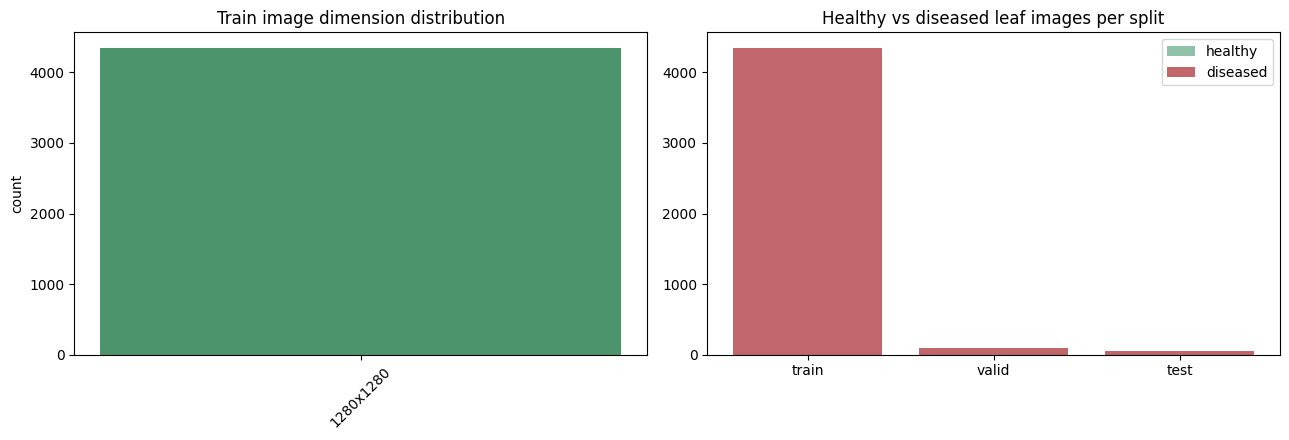

In [9]:

# ------------------------------------------------------------
# Visualize: image-dimension distribution and class balance
# ------------------------------------------------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Dimension distribution (train split)
dims = report.get("train", {}).get("unique_dims", {})
if dims:
    labels = [f"{w}x{h}" for (w, h) in dims.keys()]
    counts = list(dims.values())
    axes[0].bar(labels, counts, color="#4C956C")
    axes[0].set_title("Train image dimension distribution")
    axes[0].set_ylabel("count")
    axes[0].tick_params(axis='x', rotation=45)

# Healthy vs diseased distribution across splits
x = split_df["split"]
axes[1].bar(x, split_df["healthy_images"], label="healthy", color="#8FC1A9")
axes[1].bar(x, split_df["diseased_images"], bottom=split_df["healthy_images"], label="diseased", color="#C1666B")
axes[1].set_title("Healthy vs diseased leaf images per split")
axes[1].legend()

plt.tight_layout()
plt.savefig("data_validation_report.png", dpi=150)
plt.show()



## Task 2 — Integrated Hybrid Pipeline (Deep Learning + VLM)

2.1 Fine-tune YOLOv8-seg for leaf/lesion instance segmentation.
2.2 Pixel-ratio severity scoring: `Severity % = (Lesion Pixels / Total Leaf Pixels) * 100`.
2.3 Structured VLM verification layer (Qwen2.5-VL) that critiques the numeric score against the image.


In [10]:
!pip install -q ultralytics

In [11]:
# ============================================================
# Fix Pillow / Ultralytics compatibility
# ============================================================
!pip install -q "pillow<12" --force-reinstall

# Restart the runtime after this cell finishes
# Runtime → Restart session

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 28.7 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inference-sdk 1.5.2 requires pillow<13.0.0,>=12.3.0, but you have pillow 11.3.0 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [ ]:

# ============================================================
# 2.1 Fine-tune YOLOv8-seg
# ============================================================
from ultralytics import YOLO

seg_model = YOLO(CONFIG["MODEL_ARCH"])

train_results = seg_model.train(
    data=str(DATASET_LOCATION / "data.yaml"),
    epochs=CONFIG["EPOCHS"],
    imgsz=CONFIG["IMG_SIZE"],
    batch=CONFIG["BATCH"],
    project=CONFIG["PROJECT_DIR"],
    name=CONFIG["RUN_NAME"],
    patience=15,          # stop earlier if no improvement
    device=0,
    workers=4,            # reduce if CPU is bottleneck
    cache=True,           # cache images in RAM (faster after first epoch)
    # light field-condition robustness augmentation: lighting / occlusion variance
    hsv_h=0.02, hsv_s=0.7, hsv_v=0.5,     # lighting/color jitter
    degrees=15, translate=0.1, scale=0.5,  # geometric variance for occlusion/framing
    fliplr=0.5, mosaic=1.0, erasing=0.2,   # erasing ~ synthetic occlusion
)

BEST_WEIGHTS = str(seg_model.trainer.best)
print("Best weights:", BEST_WEIGHTS)


New https://pypi.org/project/ultralytics/8.4.143 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.253 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.2, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.5, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=leaf_lesion_seg, nbs=64, nms=Fal

### 2.1b Wiring up the literature-informed CONFIG flags

The `CONFIG` block declares three flags that referenced specific papers but were not
actually implemented anywhere in the pipeline. This cell + the rewritten `compute_severity`
below fix that gap:

- **`ENABLE_BG_SHADOW_REMOVAL`** — AISA-style background/shadow removal
  (hyper-green thresholding + GrabCut refinement), per Astani & Hasheminejad,
  *"A parallel convolutional neural network with background removal and lesion
  segmentation for field plant disease severity classification"* (BaSPaC, Sci. Reports 2026).
- **`ENABLE_DUAL_STAGE_REFINEMENT`** — crop to the detected leaf region, then
  re-run segmentation *inside* that crop to refine the lesion mask, per
  Shivaraj & Haladappa's dual-stage leaf→lesion U-Net design (ETASR 2026, Table III
  ablation) and AgriMamba's LMLS→TMLS staged architecture (Wu et al., *The Crop
  Journal*, 2026).
- **`SEVERITY_SCALE`** — bucket the continuous pixel-ratio severity into an
  ordinal grade (`linear`, `horsfall_barratt`, or `chiang`), per Chiang & Hong,
  *"植物病害量化順序尺度之優化與統計分析方法之進展"* (J. Plant Med. 2025). Per
  their guidance, the continuous `severity_pct` (an NPE-equivalent value, since it comes
  directly from segmented pixel counts) remains the number used for MAE / statistics;
  the returned grade/bucket is for reporting only and should never be averaged directly
  (see their warning on DSI(%) Eq. 2 vs. the DSIₘₒ₅ᵢᶠᵢᵉᵈ interpolation, Eq. 3).


In [ ]:

# ============================================================
# 2.1b Literature-informed preprocessing & severity-scale helpers
# ============================================================
import numpy as np
import cv2


# ---- AISA-style background/shadow removal (Astani & Hasheminejad, BaSPaC) ----
def remove_background_aisa(image_bgr, green_thresh=None):
    """
    Approximate re-implementation of the AISA algorithm described in
    Astani & Hasheminejad (2026): a hyper-green (excess-green) index is used
    to seed a foreground/background estimate, which is refined with GrabCut;
    background/shadow pixels are then suppressed while the disease lesion and
    leaf region are preserved.

    Returns a BGR image (same shape as input) with background pixels zeroed.
    Falls back to the original image untouched if GrabCut fails on a
    degenerate mask (e.g. a near-uniform crop).
    """
    img = image_bgr.astype(np.float32)
    b, g, r = cv2.split(img)

    # Hyper-green / excess-green index: 2G - R - B
    exg = 2 * g - r - b
    exg_norm = cv2.normalize(exg, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    if green_thresh is None:
        _, fg_seed = cv2.threshold(exg_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        _, fg_seed = cv2.threshold(exg_norm, green_thresh, 255, cv2.THRESH_BINARY)

    mask = np.where(fg_seed > 0, cv2.GC_PR_FGD, cv2.GC_PR_BGD).astype("uint8")
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    img_u8 = image_bgr.astype(np.uint8)

    try:
        cv2.grabCut(img_u8, mask, None, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_MASK)
        fg_mask = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 1, 0).astype("uint8")
        if fg_mask.sum() == 0:  # GrabCut collapsed to nothing usable
            fg_mask = (fg_seed > 0).astype("uint8")
    except cv2.error:
        fg_mask = (fg_seed > 0).astype("uint8")

    cleaned = img_u8.copy()
    cleaned[fg_mask == 0] = 0
    return cleaned


# ---- Disease severity ordinal scales (Chiang & Hong, J. Plant Med. 2025) ----
# Each entry: (lower_bound_pct, upper_bound_pct, midpoint_pct, label)
HORSFALL_BARRATT_SCALE = [
    (0, 0, 0.0, "HB-1 (0%)"),
    (0, 3, 1.5, "HB-2 (0-3%)"),
    (3, 6, 4.5, "HB-3 (3-6%)"),
    (6, 12, 9.0, "HB-4 (6-12%)"),
    (12, 25, 18.5, "HB-5 (12-25%)"),
    (25, 50, 37.5, "HB-6 (25-50%)"),
    (50, 75, 62.5, "HB-7 (50-75%)"),
    (75, 88, 81.5, "HB-8 (75-88%)"),
    (88, 94, 91.0, "HB-9 (88-94%)"),
    (94, 97, 95.5, "HB-10 (94-97%)"),
    (97, 100, 98.5, "HB-11 (97-100%)"),
    (100, 100, 100.0, "HB-12 (100%)"),
]

CHIANG_SCALE = [
    (0, 0, 0.0, "Chiang-0 (0%)"),
    (0, 0.1, 0.05, "Chiang-1 (0-0.1%)"),
    (0.1, 0.5, 0.30, "Chiang-2 (0.1-0.5%)"),
    (0.5, 1.0, 0.75, "Chiang-3 (0.5-1.0%)"),
    (1.0, 2.0, 1.50, "Chiang-4 (1.0-2.0%)"),
    (2.0, 5.0, 3.50, "Chiang-5 (2.0-5.0%)"),
    (5.0, 10.0, 7.50, "Chiang-6 (5.0-10%)"),
    (10.0, 20.0, 15.0, "Chiang-7 (10-20%)"),
    (20.0, 30.0, 25.0, "Chiang-8 (20-30%)"),
    (30.0, 40.0, 35.0, "Chiang-9 (30-40%)"),
    (40.0, 50.0, 45.0, "Chiang-10 (40-50%)"),
    (50.0, 60.0, 55.0, "Chiang-11 (50-60%)"),
    (60.0, 70.0, 65.0, "Chiang-12 (60-70%)"),
    (70.0, 80.0, 75.0, "Chiang-13 (70-80%)"),
    (80.0, 90.0, 85.0, "Chiang-14 (80-90%)"),
    (90.0, 100.0, 95.0, "Chiang-15 (90-100%)"),
]

# Equal-width fallback grading, e.g. Healthy/Low/Medium/High
# (thresholds follow the 4-class scheme in Shivaraj & Haladappa, Eq. 10)
LINEAR_SCALE = [
    (0, 0, 0.0, "Healthy (0%)"),
    (0, 5, 2.5, "Low (0-5%)"),
    (5, 15, 10.0, "Medium (5-15%)"),
    (15, 100, 57.5, "High (>=15%)"),
]

_SEVERITY_SCALES = {
    "linear": LINEAR_SCALE,
    "horsfall_barratt": HORSFALL_BARRATT_SCALE,
    "chiang": CHIANG_SCALE,
}


def bucket_severity(severity_pct, scale=None):
    """
    Map a continuous pixel-ratio severity percentage onto an ordinal grade
    from the scale named in CONFIG["SEVERITY_SCALE"] (or an explicit override).

    Per Chiang & Hong (2025): this bucketing is for *reporting* only. The
    continuous `severity_pct` should remain the value used for MAE, averaging,
    and any downstream statistical comparison -- do not average the returned
    grade indices directly. If an aggregate index across a sample is ever
    needed, use the returned midpoints (their DSI_Modified interpolation,
    Eq. 3) rather than the naive DSI(%) formula (their Eq. 2), which they show
    systematically overestimates severity for non-linear scales like HB.
    """
    scale_name = scale or CONFIG.get("SEVERITY_SCALE", "chiang")
    table = _SEVERITY_SCALES.get(scale_name, CHIANG_SCALE)

    if severity_pct <= 0:
        lo, hi, mid, label = table[0]
        return {"grade_index": 0, "grade_label": label, "midpoint_pct": mid, "scale": scale_name}

    for idx, (lo, hi, mid, label) in enumerate(table):
        if (lo == 0 and hi == 0):
            continue
        if lo < severity_pct <= hi:
            return {"grade_index": idx, "grade_label": label, "midpoint_pct": mid, "scale": scale_name}

    lo, hi, mid, label = table[-1]
    return {"grade_index": len(table) - 1, "grade_label": label, "midpoint_pct": mid, "scale": scale_name}


print("Loaded background-removal and severity-scale helpers.")
print("Active SEVERITY_SCALE:", CONFIG.get("SEVERITY_SCALE"))
print("Example bucket_severity(7.4):", bucket_severity(7.4))


In [ ]:

# ============================================================
# 2.2 Pixel-ratio severity scoring
# ============================================================
import numpy as np
import cv2

best_model = YOLO(BEST_WEIGHTS)
NAMES = best_model.names  # {id: name}

def classify_name(name):
    n = name.lower()
    if any(k in n for k in [c.lower() for c in CONFIG["LEAF_CLASS_NAMES"]]):
        return "leaf"
    if any(k in n for k in [c.lower() for c in CONFIG["LESION_CLASS_NAMES"]]):
        return "lesion"
    return "other"

def compute_severity(image_path, model=best_model, conf=0.25, imgsz=CONFIG["IMG_SIZE"], crop_pad_frac=0.05):
    """Run seg inference and compute Severity% = lesion_px / total_leaf_px * 100.

    Two literature-informed behaviors are applied when enabled in CONFIG
    (see the 2.1b cell above for the implementations):
      - ENABLE_BG_SHADOW_REMOVAL: AISA-style background/shadow removal is
        applied before inference (Astani & Hasheminejad, BaSPaC).
      - ENABLE_DUAL_STAGE_REFINEMENT: after the first full-image pass locates
        the leaf, the image is cropped to the leaf's bounding box and a
        second pass re-segments leaf/lesion inside that crop -- the
        crop-then-refine design used in Shivaraj & Haladappa and AgriMamba
        (LMLS -> TMLS). Crop-local masks are mapped back into full-image
        coordinates so downstream code (e.g. the failure-mode overlays in
        Task 3) is unaffected.

    'Total leaf px' = union of leaf-class mask; if no explicit leaf mask exists
    for an image, falls back to union(leaf_px, lesion_px) as the leaf proxy.
    Returns a dict with pixel counts, severity, ordinal grade (per
    CONFIG["SEVERITY_SCALE"]; see bucket_severity), and the raw result for
    plotting.
    """
    orig_bgr = image_path if isinstance(image_path, np.ndarray) else cv2.imread(str(image_path))
    h, w = orig_bgr.shape[:2]

    infer_input = orig_bgr
    bg_removed = False
    if CONFIG.get("ENABLE_BG_SHADOW_REMOVAL", False):
        infer_input = remove_background_aisa(orig_bgr)
        bg_removed = True

    def _segment(img_array):
        """Run one seg pass on a BGR array; return (leaf_mask, lesion_mask, result) at img_array's resolution."""
        ih, iw = img_array.shape[:2]
        res = model.predict(img_array, conf=conf, imgsz=imgsz, verbose=False)[0]
        leaf_m = np.zeros((ih, iw), dtype=bool)
        lesion_m = np.zeros((ih, iw), dtype=bool)
        if res.masks is not None:
            polys = res.masks.data.cpu().numpy()  # (n, mh, mw)
            cls_ids = res.boxes.cls.cpu().numpy().astype(int)
            for m, cid in zip(polys, cls_ids):
                m_resized = cv2.resize(m.astype(np.uint8), (iw, ih), interpolation=cv2.INTER_NEAREST).astype(bool)
                kind = classify_name(NAMES[cid])
                if kind == "leaf":
                    leaf_m |= m_resized
                elif kind == "lesion":
                    lesion_m |= m_resized
        return leaf_m, lesion_m, res

    # --- Stage 1: full-image pass ---
    leaf_mask, lesion_mask, result = _segment(infer_input)
    dual_stage_used = False

    # --- Stage 2 (optional): crop to leaf bbox, re-segment inside the crop ---
    if CONFIG.get("ENABLE_DUAL_STAGE_REFINEMENT", False) and leaf_mask.any():
        ys, xs = np.where(leaf_mask)
        y0, y1 = int(ys.min()), int(ys.max())
        x0, x1 = int(xs.min()), int(xs.max())
        pad_y = int((y1 - y0) * crop_pad_frac)
        pad_x = int((x1 - x0) * crop_pad_frac)
        cy0, cy1 = max(0, y0 - pad_y), min(h, y1 + pad_y + 1)
        cx0, cx1 = max(0, x0 - pad_x), min(w, x1 + pad_x + 1)

        if (cy1 - cy0) >= 32 and (cx1 - cx0) >= 32:  # skip degenerate crops
            crop = infer_input[cy0:cy1, cx0:cx1]
            leaf_mask_crop, lesion_mask_crop, refine_result = _segment(crop)

            if leaf_mask_crop.any() or lesion_mask_crop.any():
                # Map crop-local refined masks back into full-image coordinates.
                refined_leaf = np.zeros((h, w), dtype=bool)
                refined_lesion = np.zeros((h, w), dtype=bool)
                refined_leaf[cy0:cy1, cx0:cx1] = leaf_mask_crop
                refined_lesion[cy0:cy1, cx0:cx1] = lesion_mask_crop
                leaf_mask, lesion_mask = refined_leaf, refined_lesion
                result = refine_result
                dual_stage_used = True
            # else: stage-2 pass found nothing usable -> keep stage-1 masks

    total_leaf_area = leaf_mask.sum() if leaf_mask.any() else (leaf_mask | lesion_mask).sum()
    lesion_area = lesion_mask.sum()
    severity_pct = float(100.0 * lesion_area / total_leaf_area) if total_leaf_area > 0 else 0.0
    severity_grade = bucket_severity(severity_pct)

    return {
        "image_path": "<array>" if isinstance(image_path, np.ndarray) else str(image_path),
        "leaf_px": int(total_leaf_area),
        "lesion_px": int(lesion_area),
        "severity_pct": round(severity_pct, 3),
        "severity_grade": severity_grade,
        "bg_removed": bg_removed,
        "dual_stage_used": dual_stage_used,
        "leaf_mask": leaf_mask,
        "lesion_mask": lesion_mask,
        "result": result,
    }

# quick smoke test on one validation image
sample_dir = DATASET_LOCATION / "valid" / "images"
sample_img = next(sample_dir.glob("*.*"))
sev = compute_severity(sample_img)
print(sample_img.name, "-> severity %:", sev["severity_pct"],
      "| grade:", sev["severity_grade"]["grade_label"],
      "| bg_removed:", sev["bg_removed"],
      "| dual_stage_used:", sev["dual_stage_used"])


In [ ]:
# ============================================================
# 2.3 Qwen2.5-VL structured visual verification
# ============================================================

import torch
import json
import re

from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)

from qwen_vl_utils import process_vision_info


# ------------------------------------------------------------
# 1. Model configuration
# ------------------------------------------------------------

MODEL_ID = CONFIG["VLM_MODEL_ID"]

print("Loading VLM:", MODEL_ID)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2),
        "GB"
    )


# ------------------------------------------------------------
# 2. 4-bit configuration for Tesla T4
# ------------------------------------------------------------

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)


# ------------------------------------------------------------
# 3. Load Qwen2.5-VL
# ------------------------------------------------------------

vlm_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)

vlm_model.eval()


# ------------------------------------------------------------
# 4. Processor
# ------------------------------------------------------------

vlm_processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    use_fast=False,
)

print("VLM loaded successfully.")

In [ ]:
# ============================================================
# 2.3A — BASIC VLM CONNECTION TEST
# ============================================================

def vlm_basic_test(image_path):

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": str(image_path),
                },
                {
                    "type": "text",
                    "text": (
                        "Look at this plant leaf. "
                        "Briefly describe what you see. "
                        "Mention whether you can see visible spots or lesions."
                    ),
                },
            ],
        }
    ]

    # Convert messages to Qwen format
    text = vlm_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    # Extract image
    image_inputs, video_inputs = process_vision_info(messages)

    # Processor
    inputs = vlm_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

    # Move tensors to model device
    inputs = {
        k: v.to(vlm_model.device) if torch.is_tensor(v) else v
        for k, v in inputs.items()
    }

    # Generate
    with torch.inference_mode():

        generated_ids = vlm_model.generate(
            **inputs,
            max_new_tokens=100,
            do_sample=False,
        )

    # Remove prompt tokens
    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs["input_ids"],
            generated_ids
        )
    ]

    # Decode
    output = vlm_processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

    return output.strip()

In [ ]:
basic_output = vlm_basic_test(sample_img)

print("\n==============================")
print("QWEN BASIC TEST")
print("==============================")
print(basic_output)

In [ ]:
# ============================================================
# 2.3B — STRUCTURED VLM VERIFICATION
# ============================================================

VLM_SYSTEM_PROMPT = """
You are a plant pathology visual auditor.

You receive an image of a plant leaf and a lesion severity
percentage calculated by a deep-learning segmentation model.

Your job is to visually judge whether the numerical severity
estimate is plausible from the leaf image.

IMPORTANT:
Do not calculate a new percentage.
Do not replace the segmentation model.
Only judge whether the supplied percentage is visually plausible.

Return ONLY valid JSON.

The JSON must have exactly these fields:

{
  "visual_severity_bracket": "...",
  "confidence": 0.0,
  "flags": ["..."]
}

Allowed visual_severity_bracket values:

"healthy(0-2%)"
"low(2-10%)"
"moderate(10-25%)"
"high(25-50%)"
"severe(>50%)"

Allowed flags:

"lighting_glare"
"soil_or_background_noise"
"overlapping_leaves"
"boundary_occlusion"
"blur"
"none"

The confidence must be a number between 0 and 1.

Return JSON only.
"""


def vlm_verify(
    image_path,
    dl_severity_pct,
    max_new_tokens=128
):

    messages = [
        {
            "role": "system",
            "content": [
                {
                    "type": "text",
                    "text": VLM_SYSTEM_PROMPT
                }
            ],
        },

        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": str(image_path),
                },

                {
                    "type": "text",
                    "text": (
                        f"Deep-learning severity estimate: "
                        f"{dl_severity_pct:.3f}%.\n\n"
                        "Visually audit this estimate. "
                        "Return JSON only."
                    ),
                },
            ],
        },
    ]


    # --------------------------------------------------------
    # Build Qwen prompt
    # --------------------------------------------------------

    text = vlm_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )


    # --------------------------------------------------------
    # Process image
    # --------------------------------------------------------

    image_inputs, video_inputs = process_vision_info(
        messages
    )


    # --------------------------------------------------------
    # Create model inputs
    # --------------------------------------------------------

    inputs = vlm_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )


    # --------------------------------------------------------
    # Move tensors to GPU
    # --------------------------------------------------------

    inputs = {
        k: v.to(vlm_model.device) if torch.is_tensor(v) else v
        for k, v in inputs.items()
    }


    # --------------------------------------------------------
    # Generate
    # --------------------------------------------------------

    with torch.inference_mode():

        generated_ids = vlm_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )


    # --------------------------------------------------------
    # Remove input tokens
    # --------------------------------------------------------

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs["input_ids"],
            generated_ids
        )
    ]


    # --------------------------------------------------------
    # Decode
    # --------------------------------------------------------

    raw = vlm_processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()


    print("\n==============================")
    print("RAW VLM OUTPUT")
    print("==============================")
    print(raw)
    print("==============================\n")


    # --------------------------------------------------------
    # Extract JSON
    # --------------------------------------------------------

    raw_clean = raw.strip()

    # Remove markdown fences if present
    raw_clean = re.sub(
        r"^```json\s*",
        "",
        raw_clean,
        flags=re.IGNORECASE
    )

    raw_clean = re.sub(
        r"\s*```$",
        "",
        raw_clean
    )

    # Find JSON object
    match = re.search(
        r"\{.*\}",
        raw_clean,
        re.DOTALL
    )

    if not match:

        return {
            "error": "unparsable",
            "raw": raw
        }


    json_text = match.group(0)


    try:

        parsed = json.loads(json_text)

    except json.JSONDecodeError:

        return {
            "error": "invalid_json",
            "raw": raw,
            "json_candidate": json_text
        }


    # --------------------------------------------------------
    # Validate required fields
    # --------------------------------------------------------

    required_fields = [
        "visual_severity_bracket",
        "confidence",
        "flags"
    ]

    missing = [
        f for f in required_fields
        if f not in parsed
    ]

    if missing:

        return {
            "error": "missing_fields",
            "missing": missing,
            "raw": raw,
            "parsed": parsed
        }


    return parsed

In [ ]:
verdict = vlm_verify(sample_img, sev["severity_pct"])
print(json.dumps(verdict, indent=2))

In [ ]:

# ------------------------------------------------------------
# 2.4 End-to-end hybrid execution: DL scoring + VLM critique, bound together
# ------------------------------------------------------------
def run_hybrid_pipeline(image_path):
    dl = compute_severity(image_path)
    vlm = vlm_verify(image_path, dl["severity_pct"])
    return {
        "image": str(image_path),
        "dl_severity_pct": dl["severity_pct"],
        "dl_leaf_px": dl["leaf_px"],
        "dl_lesion_px": dl["lesion_px"],
        "vlm_verdict": vlm,
    }

hybrid_out = run_hybrid_pipeline(sample_img)
print(json.dumps(hybrid_out, indent=2))



## Task 3 — Metric Evaluation & Cross-Verification Diagnostics

3.1 Mask mAP@50 (leaf & lesion classes) on the held-out test split.
3.2 Severity MAE vs. ground-truth pixel-ratio severity computed from GT polygons.
3.3 DL-severity vs. VLM-confidence cross-verification matrix, with outlier flagging.
3.4 Failure-mode analysis (GT vs. Prediction side-by-side).


In [ ]:

# ============================================================
# 3.1 Mask mAP@50 on the test split
# ============================================================
val_metrics = best_model.val(
    data=str(DATASET_LOCATION / "data.yaml"),
    split="test",
    imgsz=CONFIG["IMG_SIZE"],
)

print("Box  mAP50 :", val_metrics.box.map50)
print("Mask mAP50 :", val_metrics.seg.map50)
print("Mask mAP50-95:", val_metrics.seg.map)
per_class_map50 = dict(zip(NAMES.values(), val_metrics.seg.maps))
print("Per-class mask mAP50-95:", per_class_map50)


In [ ]:

# ============================================================
# 3.2 Ground-truth severity (from label polygons) vs. predicted severity -> MAE
# ============================================================
from PIL import Image as PILImage
def gt_severity_from_label(label_path, img_w, img_h):
    leaf_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    lesion_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    lines = [l for l in Path(label_path).read_text().splitlines() if l.strip()]
    for line in lines:
        parts = line.split()
        cid = int(parts[0])
        coords = list(map(float, parts[1:]))
        pts = np.array(coords, dtype=np.float32).reshape(-1, 2)
        pts[:, 0] *= img_w
        pts[:, 1] *= img_h
        pts = pts.astype(np.int32)
        kind = classify_name(CLASS_NAMES[cid])
        target = leaf_mask if kind == "leaf" else (lesion_mask if kind == "lesion" else None)
        if target is not None:
            cv2.fillPoly(target, [pts], 1)
    total_leaf = leaf_mask.sum() if leaf_mask.sum() > 0 else (leaf_mask | lesion_mask).sum()
    lesion_area = lesion_mask.sum()
    return float(100.0 * lesion_area / total_leaf) if total_leaf > 0 else 0.0

test_img_dir = DATASET_LOCATION / "test" / "images"
test_lbl_dir = DATASET_LOCATION / "test" / "labels"

rows = []
for img_path in sorted(test_img_dir.glob("*.*")):
    lbl_path = test_lbl_dir / (img_path.stem + ".txt")
    if not lbl_path.exists():
        continue
    with PILImage.open(img_path) as im:
        w, h = im.size
    gt_pct = gt_severity_from_label(lbl_path, w, h)
    pred = compute_severity(img_path)
    rows.append({"image": img_path.name, "gt_severity_pct": gt_pct, "pred_severity_pct": pred["severity_pct"]})

severity_df = pd.DataFrame(rows)
severity_df["abs_error"] = (severity_df["gt_severity_pct"] - severity_df["pred_severity_pct"]).abs()
mae = severity_df["abs_error"].mean()
print(f"Severity MAE on test set: {mae:.3f} percentage points (n={len(severity_df)})")
severity_df.head(10)


In [ ]:
# ============================================================
# 3.3 DL severity vs. VLM visual severity cross-verification
# ============================================================

def severity_bracket(severity_pct):
    """
    Convert DL-computed severity (%) into the same severity
    categories used by the VLM.
    """
    if severity_pct <= 2:
        return "healthy"
    elif severity_pct <= 10:
        return "low"
    elif severity_pct <= 25:
        return "moderate"
    elif severity_pct <= 50:
        return "high"
    else:
        return "severe"


def normalize_vlm_bracket(bracket):
    """
    Convert VLM output such as 'healthy(0-2%)'
    into a simple category.
    """
    if not isinstance(bracket, str):
        return None

    bracket = bracket.lower().strip()

    if bracket.startswith("healthy"):
        return "healthy"
    elif bracket.startswith("low"):
        return "low"
    elif bracket.startswith("moderate"):
        return "moderate"
    elif bracket.startswith("high"):
        return "high"
    elif bracket.startswith("severe"):
        return "severe"

    return None


def bracket_distance(dl_bracket, vlm_bracket):
    """
    Measure how far apart the two severity categories are.

    0 = same category
    1 = adjacent category
    2+ = substantial disagreement
    """
    order = {
        "healthy": 0,
        "low": 1,
        "moderate": 2,
        "high": 3,
        "severe": 4,
    }

    if dl_bracket not in order or vlm_bracket not in order:
        return np.nan

    return abs(order[dl_bracket] - order[vlm_bracket])


cross_rows = []

for _, r in severity_df.iterrows():

    img_path = test_img_dir / r["image"]

    verdict = vlm_verify(
        img_path,
        r["pred_severity_pct"]
    )

    conf = verdict.get("confidence", np.nan)

    vlm_bracket_raw = verdict.get(
        "visual_severity_bracket",
        None
    )

    # DL severity category
    dl_bracket = severity_bracket(
        r["pred_severity_pct"]
    )

    # VLM severity category
    vlm_bracket = normalize_vlm_bracket(
        vlm_bracket_raw
    )

    # Distance between categories
    distance = bracket_distance(
        dl_bracket,
        vlm_bracket
    )

    # Confidence check
    try:
        conf_value = float(conf)
    except (TypeError, ValueError):
        conf_value = np.nan

    # --------------------------------------------------------
    # Final cross-verification decision
    # --------------------------------------------------------

    if vlm_bracket is None:
        verification = "uncertain"

    elif np.isnan(conf_value):
        verification = "uncertain"

    elif conf_value < CONFIG["VLM_CONFIDENCE_THRESHOLD"]:
        verification = "uncertain"

    elif distance == 0:
        verification = "agree"

    elif distance == 1:
        verification = "borderline"

    else:
        verification = "disagree"

    cross_rows.append({
        "image": r["image"],
        "dl_severity_pct": r["pred_severity_pct"],
        "gt_severity_pct": r["gt_severity_pct"],

        "dl_severity_bracket": dl_bracket,
        "vlm_severity_bracket": vlm_bracket,

        "vlm_confidence": conf_value,
        "bracket_distance": distance,

        "verification": verification,

        "vlm_flags": ",".join(
            verdict.get("flags", [])
        ) if isinstance(verdict.get("flags"), list)
        else verdict.get("flags"),
    })


cross_df = pd.DataFrame(cross_rows)


# ============================================================
# Summary
# ============================================================

n_agree = int(
    (cross_df["verification"] == "agree").sum()
)

n_borderline = int(
    (cross_df["verification"] == "borderline").sum()
)

n_disagree = int(
    (cross_df["verification"] == "disagree").sum()
)

n_uncertain = int(
    (cross_df["verification"] == "uncertain").sum()
)


print("DL vs. VLM Cross-Verification")
print("--------------------------------")
print(f"Agree:       {n_agree}")
print(f"Borderline:  {n_borderline}")
print(f"Disagree:    {n_disagree}")
print(f"Uncertain:   {n_uncertain}")
print(f"Total:       {len(cross_df)}")


# ============================================================
# Visualization
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

plot_df = cross_df.dropna(
    subset=["vlm_confidence"]
)

ax.scatter(
    plot_df["dl_severity_pct"],
    plot_df["vlm_confidence"],
    s=60,
    edgecolor="k"
)

ax.set_xlabel(
    "DL-calculated severity (%)"
)

ax.set_ylabel(
    "VLM confidence (0-1)"
)

ax.set_title(
    "DL vs. VLM Cross-Verification"
)

plt.tight_layout()

plt.savefig(
    "cross_verification_matrix.png",
    dpi=150
)

plt.show()


# ============================================================
# Show strongest disagreements
# ============================================================

cross_df[
    cross_df["verification"] == "disagree"
].sort_values(
    "bracket_distance",
    ascending=False
).head(10)

In [ ]:

# ============================================================
# 3.4 Failure-mode analysis: GT vs Prediction side-by-side
# ============================================================
def draw_mask_overlay(image_path, mask, color=(255, 0, 0), alpha=0.45):
    img = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    overlay = img.copy()
    overlay[mask.astype(bool)] = color
    return cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

def gt_masks_from_label(label_path, img_w, img_h):
    leaf_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    lesion_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    for line in [l for l in Path(label_path).read_text().splitlines() if l.strip()]:
        parts = line.split()
        cid = int(parts[0])
        pts = np.array(list(map(float, parts[1:])), dtype=np.float32).reshape(-1, 2)
        pts[:, 0] *= img_w; pts[:, 1] *= img_h
        pts = pts.astype(np.int32)
        kind = classify_name(CLASS_NAMES[cid])
        target = leaf_mask if kind == "leaf" else (lesion_mask if kind == "lesion" else None)
        if target is not None:
            cv2.fillPoly(target, [pts], 1)
    return leaf_mask.astype(bool), lesion_mask.astype(bool)

worst_cases = severity_df.sort_values("abs_error", ascending=False).head(4)

fig, axes = plt.subplots(len(worst_cases), 2, figsize=(9, 4 * len(worst_cases)))
if len(worst_cases) == 1:
    axes = axes.reshape(1, 2)

for i, (_, row) in enumerate(worst_cases.iterrows()):
    img_path = test_img_dir / row["image"]
    lbl_path = test_lbl_dir / (Path(row["image"]).stem + ".txt")
    with PILImage.open(img_path) as im:
        w, h = im.size
    _, gt_lesion = gt_masks_from_label(lbl_path, w, h)
    pred = compute_severity(img_path)

    axes[i, 0].imshow(draw_mask_overlay(img_path, gt_lesion, color=(0, 200, 0)))
    axes[i, 0].set_title(f"GT  |  {row['image']}  |  {row['gt_severity_pct']:.1f}%")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(draw_mask_overlay(img_path, pred["lesion_mask"], color=(255, 0, 0)))
    axes[i, 1].set_title(f"Pred  |  err={row['abs_error']:.1f}pp  |  {pred['severity_pct']:.1f}%")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig("failure_mode_analysis.png", dpi=150)
plt.show()



## Task 4 — Multi-Model Packaging & Serving Architecture

4.1 Export the segmentation model to ONNX (and note the TensorRT path).
4.2 Serving architecture: FastAPI service + Docker container + edge-orchestration notes.


In [ ]:

# ============================================================
# 4.1 Export to ONNX / TensorRT
# ============================================================
onnx_path = best_model.export(format="onnx", dynamic=True, simplify=True, opset=17)
print("ONNX export ->", onnx_path)

import shutil
shutil.copy(onnx_path, os.path.join(CONFIG["EXPORT_DIR"], "leaf_lesion_seg.onnx"))
shutil.copy(BEST_WEIGHTS, os.path.join(CONFIG["EXPORT_DIR"], "leaf_lesion_seg.pt"))

# TensorRT (only works on a machine with TensorRT + matching CUDA installed, e.g. Colab GPU runtime,
# or the target edge/server box). Uncomment on a TensorRT-capable environment:
# engine_path = best_model.export(format="engine", dynamic=True, half=True, workspace=4)
# print("TensorRT engine ->", engine_path)

print("\\nExport directory contents:")
print(os.listdir(CONFIG["EXPORT_DIR"]))


In [ ]:
# ============================================================
# 4.2 FastAPI serving app (written to disk for containerization)
# ============================================================

In [ ]:
%%writefile serving/app.py

"""
FastAPI service for the complete hybrid pipeline:

Image
  -> YOLOv8-seg inference
  -> Leaf/lesion pixel masks
  -> Numerical severity scoring
  -> Qwen2.5-VL visual verification
  -> Deterministic cross-verification
  -> Structured JSON response

Run locally:
    uvicorn app:app --host 0.0.0.0 --port 8080

Expected pipeline:
    DL inference -> severity scoring -> VLM verification
"""

import io
import json
import re
import numpy as np
import cv2
import torch

from fastapi import FastAPI, UploadFile, File, HTTPException
from fastapi.responses import JSONResponse
from PIL import Image

from ultralytics import YOLO

# Qwen2.5-VL
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)
from qwen_vl_utils import process_vision_info


# ============================================================
# 1. API
# ============================================================

app = FastAPI(
    title="Leaf Lesion Severity Scoring API",
    description=(
        "Hybrid plant disease assessment pipeline: "
        "YOLOv8-seg -> pixel severity scoring -> Qwen2.5-VL verification"
    ),
    version="2.0.0",
)


# ============================================================
# 2. Configuration
# ============================================================

MODEL_PATH = "leaf_lesion_seg.onnx"

VLM_MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

VLM_CONFIDENCE_THRESHOLD = 0.70

# Dataset class mapping:
# class 0 = leaf
# class 1 = lesion
LEAF_CLASS_IDS = {0}
LESION_CLASS_IDS = {1}


# ============================================================
# 3. Load YOLO segmentation model
# ============================================================

print(f"Loading segmentation model: {MODEL_PATH}")

model = YOLO(
    MODEL_PATH,
    task="segment"
)

NAMES = model.names

print(f"Segmentation classes: {NAMES}")


# ============================================================
# 4. Load Qwen2.5-VL
# ============================================================

print(f"Loading VLM: {VLM_MODEL_ID}")

VLM_AVAILABLE = False
vlm_model = None
vlm_processor = None

try:

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    vlm_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        VLM_MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.float16,
    )

    vlm_model.eval()

    vlm_processor = AutoProcessor.from_pretrained(
        VLM_MODEL_ID,
        use_fast=False,
    )

    VLM_AVAILABLE = True

    print("Qwen2.5-VL loaded successfully.")

except Exception as e:

    print(f"WARNING: Qwen2.5-VL could not be loaded: {e}")
    print("The API will still start, but VLM verification will be unavailable.")


# ============================================================
# 5. Severity brackets
# ============================================================

SEVERITY_ORDER = {
    "healthy": 0,
    "low": 1,
    "moderate": 2,
    "high": 3,
    "severe": 4,
}


def severity_bracket(severity_pct: float) -> str:

    if severity_pct <= 2:
        return "healthy"

    elif severity_pct <= 10:
        return "low"

    elif severity_pct <= 25:
        return "moderate"

    elif severity_pct <= 50:
        return "high"

    else:
        return "severe"


# ============================================================
# 6. Normalize VLM bracket
# ============================================================

def normalize_vlm_bracket(bracket):

    if not isinstance(bracket, str):
        return None

    value = bracket.lower().strip()

    if value.startswith("healthy"):
        return "healthy"

    if value.startswith("low"):
        return "low"

    if value.startswith("moderate"):
        return "moderate"

    if value.startswith("high"):
        return "high"

    if value.startswith("severe"):
        return "severe"

    return None


# ============================================================
# 7. Bracket distance
# ============================================================

def bracket_distance(dl_bracket, vlm_bracket):

    if dl_bracket not in SEVERITY_ORDER:
        return None

    if vlm_bracket not in SEVERITY_ORDER:
        return None

    return abs(
        SEVERITY_ORDER[dl_bracket]
        - SEVERITY_ORDER[vlm_bracket]
    )


# ============================================================
# 8. YOLO segmentation + numerical severity
# ============================================================

def compute_severity(
    image: np.ndarray,
    conf: float = 0.25
):

    h, w = image.shape[:2]

    result = model.predict(
        image,
        conf=conf,
        verbose=False
    )[0]

    leaf_mask = np.zeros(
        (h, w),
        dtype=bool
    )

    lesion_mask = np.zeros(
        (h, w),
        dtype=bool
    )

    if result.masks is not None:

        masks = result.masks.data.cpu().numpy()

        class_ids = (
            result.boxes.cls
            .cpu()
            .numpy()
            .astype(int)
        )

        for mask, class_id in zip(
            masks,
            class_ids
        ):

            resized_mask = cv2.resize(
                mask.astype(np.uint8),
                (w, h),
                interpolation=cv2.INTER_NEAREST
            ).astype(bool)

            if class_id in LEAF_CLASS_IDS:

                leaf_mask |= resized_mask

            elif class_id in LESION_CLASS_IDS:

                lesion_mask |= resized_mask

    # --------------------------------------------------------
    # Calculate leaf area
    # --------------------------------------------------------

    if leaf_mask.any():

        total_leaf = int(
            leaf_mask.sum()
        )

    else:

        # Fallback if the model detects lesions but no explicit
        # leaf mask.
        total_leaf = int(
            (leaf_mask | lesion_mask).sum()
        )

    lesion_area = int(
        lesion_mask.sum()
    )

    # --------------------------------------------------------
    # Severity percentage
    # --------------------------------------------------------

    if total_leaf > 0:

        severity_pct = (
            100.0
            * lesion_area
            / total_leaf
        )

    else:

        severity_pct = 0.0

    bracket = severity_bracket(
        severity_pct
    )

    return {
        "leaf_px": total_leaf,
        "lesion_px": lesion_area,
        "severity_pct": round(
            float(severity_pct),
            3
        ),
        "severity_bracket": bracket,
    }


# ============================================================
# 9. Qwen2.5-VL visual verification prompt
# ============================================================

VLM_SYSTEM_PROMPT = """
You are a plant pathology visual auditor.

You receive:
1. An image of a plant leaf.
2. A severity percentage calculated independently by a
   deep-learning segmentation model.

Your job is to visually assess whether the supplied
severity estimate is visually plausible.

IMPORTANT:
- Do NOT calculate a new percentage.
- Do NOT replace the segmentation model.
- Do NOT estimate the exact lesion percentage.
- Independently judge the visible disease severity.
- Return ONLY valid JSON.
- Do not include Markdown.
- Do not include explanations outside the JSON.

Use exactly these fields:

{
  "visual_severity_bracket": "low",
  "confidence": 0.0,
  "flags": ["none"]
}

Allowed visual_severity_bracket values:

"healthy"
"low"
"moderate"
"high"
"severe"

Interpretation:

healthy = 0-2%
low = >2-10%
moderate = >10-25%
high = >25-50%
severe = >50%

Allowed flags:

"lighting_glare"
"soil_or_background_noise"
"overlapping_leaves"
"boundary_occlusion"
"blur"
"none"

Confidence must be a number between 0 and 1.
"""


# ============================================================
# 10. Extract JSON safely from VLM output
# ============================================================

def extract_json(text: str):

    text = text.strip()

    # Remove Markdown code fences if Qwen adds them
    text = re.sub(
        r"^```(?:json)?\s*",
        "",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r"\s*```$",
        "",
        text
    )

    # Try direct JSON parsing first
    try:

        return json.loads(text)

    except Exception:

        pass

    # Otherwise find the first JSON object
    match = re.search(
        r"\{.*\}",
        text,
        flags=re.DOTALL
    )

    if match:

        try:

            return json.loads(
                match.group(0)
            )

        except Exception:

            return None

    return None


# ============================================================
# 11. VLM verification
# ============================================================

def vlm_verify(
    image: Image.Image,
    dl_severity_pct: float
):

    if not VLM_AVAILABLE:

        return {
            "status": "unavailable",
            "visual_severity_bracket": None,
            "confidence": None,
            "flags": [
                "vlm_unavailable"
            ],
        }

    messages = [

        {
            "role": "system",
            "content": [
                {
                    "type": "text",
                    "text": VLM_SYSTEM_PROMPT,
                }
            ],
        },

        {
            "role": "user",
            "content": [

                {
                    "type": "image",
                    "image": image,
                },

                {
                    "type": "text",
                    "text": (
                        f"Deep-learning severity estimate: "
                        f"{dl_severity_pct:.3f}%.\n\n"
                        "Visually audit this estimate. "
                        "Return JSON only."
                    ),
                },
            ],
        },
    ]

    # --------------------------------------------------------
    # Convert conversation to model input
    # --------------------------------------------------------

    text = vlm_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    image_inputs, video_inputs = process_vision_info(
        messages
    )

    inputs = vlm_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

    # Move tensors to model device
    inputs = {
        key: value.to(vlm_model.device)
        if hasattr(value, "to")
        else value
        for key, value in inputs.items()
    }

    # --------------------------------------------------------
    # Generate
    # --------------------------------------------------------

    with torch.no_grad():

        generated_ids = vlm_model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
        )

    # Remove prompt tokens
    input_length = inputs["input_ids"].shape[1]

    generated_ids_trimmed = [
        output_ids[input_length:]
        for output_ids in generated_ids
    ]

    output_text = vlm_processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

    # --------------------------------------------------------
    # Parse JSON
    # --------------------------------------------------------

    parsed = extract_json(
        output_text
    )

    if not isinstance(parsed, dict):

        return {
            "status": "invalid_output",
            "visual_severity_bracket": None,
            "confidence": None,
            "flags": [
                "invalid_vlm_json"
            ],
        }

    # --------------------------------------------------------
    # Validate bracket
    # --------------------------------------------------------

    bracket = normalize_vlm_bracket(
        parsed.get(
            "visual_severity_bracket"
        )
    )

    # --------------------------------------------------------
    # Validate confidence
    # --------------------------------------------------------

    try:

        confidence = float(
            parsed.get(
                "confidence"
            )
        )

    except (
        TypeError,
        ValueError
    ):

        confidence = None

    if confidence is not None:

        confidence = max(
            0.0,
            min(1.0, confidence)
        )

    # --------------------------------------------------------
    # Validate flags
    # --------------------------------------------------------

    flags = parsed.get(
        "flags",
        ["none"]
    )

    if not isinstance(
        flags,
        list
    ):

        flags = [
            str(flags)
        ]

    return {
        "status": "ok",
        "visual_severity_bracket": bracket,
        "confidence": confidence,
        "flags": flags,
    }


# ============================================================
# 12. Deterministic cross-verification
# ============================================================

def cross_verify(
    dl_bracket,
    vlm_bracket,
    vlm_confidence
):

    # No valid VLM result
    if vlm_bracket is None:

        return {
            "status": "uncertain",
            "bracket_distance": None,
        }

    # No valid confidence
    if vlm_confidence is None:

        return {
            "status": "uncertain",
            "bracket_distance": None,
        }

    # Low VLM confidence
    if vlm_confidence < VLM_CONFIDENCE_THRESHOLD:

        distance = bracket_distance(
            dl_bracket,
            vlm_bracket
        )

        return {
            "status": "uncertain",
            "bracket_distance": distance,
        }

    distance = bracket_distance(
        dl_bracket,
        vlm_bracket
    )

    if distance == 0:

        status = "agree"

    elif distance == 1:

        status = "borderline"

    else:

        status = "disagree"

    return {
        "status": status,
        "bracket_distance": distance,
    }


# ============================================================
# 13. Health endpoint
# ============================================================

@app.get("/health")
def health():

    return {
        "status": "ok",
        "dl_model": "loaded",
        "vlm_model": (
            "loaded"
            if VLM_AVAILABLE
            else "unavailable"
        ),
    }


# ============================================================
# 14. Main scoring endpoint
# ============================================================

@app.post("/score")
async def score(
    file: UploadFile = File(...)
):

    # --------------------------------------------------------
    # Validate file type
    # --------------------------------------------------------

    if file.content_type not in (
        "image/jpeg",
        "image/png",
        "image/jpg",
    ):

        raise HTTPException(
            status_code=400,
            detail="Upload a JPEG or PNG image."
        )

    # --------------------------------------------------------
    # Read image
    # --------------------------------------------------------

    raw = await file.read()

    if not raw:

        raise HTTPException(
            status_code=400,
            detail="Empty image file."
        )

    try:

        image = Image.open(
            io.BytesIO(raw)
        ).convert("RGB")

    except Exception:

        raise HTTPException(
            status_code=400,
            detail="Invalid image file."
        )

    # --------------------------------------------------------
    # Convert to NumPy/OpenCV format
    # --------------------------------------------------------

    img_rgb = np.array(
        image
    )

    img_bgr = cv2.cvtColor(
        img_rgb,
        cv2.COLOR_RGB2BGR
    )

    # ========================================================
    # STAGE 1: DL INFERENCE + SEVERITY SCORING
    # ========================================================

    dl_result = compute_severity(
        img_bgr
    )

    # ========================================================
    # STAGE 2: VLM VISUAL VERIFICATION
    # ========================================================

    vlm_result = vlm_verify(
        image=image,
        dl_severity_pct=dl_result[
            "severity_pct"
        ],
    )

    # ========================================================
    # STAGE 3: CROSS-VERIFICATION
    # ========================================================

    cross_result = cross_verify(

        dl_bracket=dl_result[
            "severity_bracket"
        ],

        vlm_bracket=vlm_result.get(
            "visual_severity_bracket"
        ),

        vlm_confidence=vlm_result.get(
            "confidence"
        ),
    )

    # ========================================================
    # FINAL RESPONSE
    # ========================================================

    response = {

        "pipeline": [
            "dl_inference",
            "severity_scoring",
            "vlm_verification",
            "cross_verification",
        ],

        "image": {
            "filename": file.filename,
            "content_type": file.content_type,
        },

        "dl_measurement": dl_result,

        "vlm_validation": vlm_result,

        "cross_verification": cross_result,
    }

    return JSONResponse(
        content=response
    )

In [ ]:
# ============================================================
# 4.3 Dockerfile
# ============================================================

In [ ]:
%%writefile serving/Dockerfile
FROM nvidia/cuda:12.1.1-cudnn8-runtime-ubuntu22.04

ENV DEBIAN_FRONTEND=noninteractive
RUN apt-get update && apt-get install -y python3 python3-pip libgl1 libglib2.0-0 && rm -rf /var/lib/apt/lists/*

WORKDIR /app
COPY requirements.txt .
RUN pip3 install --no-cache-dir -r requirements.txt

COPY app.py .
COPY leaf_lesion_seg.onnx .

EXPOSE 8080
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8080"]

In [ ]:

%%writefile serving/requirements.txt
fastapi
uvicorn[standard]
ultralytics
onnxruntime-gpu
opencv-python-headless
pillow
numpy



### 4.4 Operational design layout

```
                    ┌───────────────────────────────────────────────┐
                    │                Client / Edge Device            │
                    │   (field camera, mobile app, kiosk, drone)      │
                    └───────────────────────┬───────────────────────┘
                                             │ HTTPS multipart image
                                             ▼
┌────────────────────────────────────────────────────────────────────────┐
│                       API Gateway / Load Balancer                       │
└───────────────────────────────┬──────────────────────────────────────┘
                                 ▼
        ┌────────────────────────────────────────────────────┐
        │  FastAPI "scoring" service (Docker container, GPU)   │
        │  1. Decode image                                     │
        │  2. YOLOv8-seg (ONNX Runtime-GPU or TensorRT engine)  │
        │  3. Pixel-ratio severity calc                         │
        │  4. (async) call VLM verification microservice        │
        │  5. Merge DL + VLM -> structured JSON response         │
        └───────────────┬───────────────────────┬─────────────┘
                         │                       │
                         ▼                       ▼
        ┌─────────────────────────┐   ┌────────────────────────────┐
        │ Segmentation inference   │   │ VLM verification service    │
        │ - ONNX Runtime (edge,    │   │ - Qwen2.5-VL / PaliGemma /   │
        │   CPU/NPU) or TensorRT   │   │   LLaVA, served separately   │
        │   engine (server GPU)    │   │   (own GPU pool, batched,     │
        │ - Triton Inference Server│   │   quantized 4-bit)            │
        │   for multi-model batching│  └────────────────────────────┘
        └─────────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────────────────┐
        │  Observability & drift monitoring                    │
        │  - Log DL severity, VLM confidence, disagreement flag │
        │  - Cross-verification dashboard (Task 3 matrix, live) │
        │  - Alert when disagreement rate exceeds threshold      │
        └────────────────────────────────────────────────────┘
```

**Deployment notes**
- **Edge / field devices** (limited compute, variable lighting): export the YOLOv8-seg model to **ONNX** and run via **ONNX Runtime** (CPU or mobile NPU/EP); skip the VLM on-device and batch-upload flagged/uncertain frames to the cloud VLM service for verification.
- **Server / greenhouse gateway** (GPU available): export to a **TensorRT engine** for lowest-latency segmentation, and run the quantized VLM as a second container so a GPU-bound VLM batch job never blocks the fast segmentation path.
- **Multi-model orchestration**: use **NVIDIA Triton Inference Server** (or a simple two-container Docker Compose) to host the segmentation ONNX/TensorRT model and the VLM behind separate endpoints, each with independent autoscaling — segmentation is cheap and should scale aggressively; the VLM is expensive and should be rate-limited/queued.
- **Docker Compose** sketch:
  ```yaml
  services:
    scoring-api:
      build: ./serving
      ports: ["8080:8080"]
      deploy: {resources: {reservations: {devices: [{capabilities: [gpu]}]}}}
    vlm-service:
      image: your-registry/vlm-verifier:latest
      deploy: {resources: {reservations: {devices: [{capabilities: [gpu]}]}}}
  ```



## Summary of Outputs
| Artifact | Location |
|---|---|
| Trained weights | `runs/severity_seg/leaf_lesion_seg/weights/best.pt` |
| ONNX export | `export/leaf_lesion_seg.onnx` |
| Data validation report | `data_validation_report.png` |
| Cross-verification matrix | `cross_verification_matrix.png` |
| Failure-mode gallery | `failure_mode_analysis.png` |
| Severity MAE table | `severity_df` (in-notebook DataFrame) |
| FastAPI service | `serving/app.py`, `serving/Dockerfile`, `serving/requirements.txt` |

**Next steps:** swap `yolov8s-seg.pt` for `yolo11s-seg.pt` or a SAM-3-distilled backbone for a possible accuracy bump; replace the disagreement heuristic in §3.3 with a calibrated logistic model once enough flagged cases have been manually reviewed; and wire `VLM_ENABLED=True` in `serving/app.py` once the VLM microservice is deployed.
